In [1]:

# 1. Instalación forzada (solo si es necesario, no afecta si ya existen)
import sys
!{sys.executable} -m pip install -q pvlib pandas pyserial matplotlib numpy
import sys
!{sys.executable} -m pip install ipywidgets

# 2. Importaciones de sistema y manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import serial
from datetime import datetime

# 3. Importación de PVLib (Energía Solar)
import pvlib
from pvlib.solarposition import get_solarposition
from pvlib.irradiance import get_total_irradiance
from pvlib.temperature import faiman
from pvlib.pvsystem import singlediode

# 4. Verificación y Reporte
print("✅ Librerías cargadas correctamente.")
print(f"--- Reporte de Versiones ---")
print(f"Pandas version: {pd.__version__}")
print(f"PVLib version:  {pvlib.__version__}")
print(f"Numpy version:  {np.__version__}")
print(f"----------------------------")
print("🚀 Entorno listo para procesar datos de la NASA y simular el Array PV.")

You should consider upgrading via the 'c:\Users\santi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\santi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


✅ Librerías cargadas correctamente.
--- Reporte de Versiones ---
Pandas version: 2.2.2
PVLib version:  0.13.0
Numpy version:  1.26.4
----------------------------
🚀 Entorno listo para procesar datos de la NASA y simular el Array PV.


https://power.larc.nasa.gov/data-access-viewer/

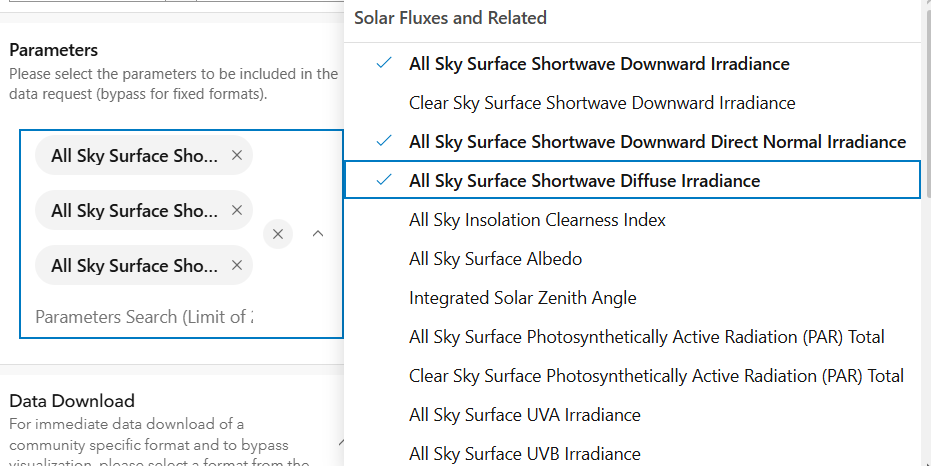
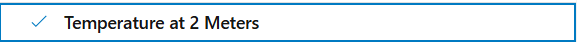

# 1. Carga de Datos y Configuración del Sistema

Esta etapa inicial procesa el archivo descargado de la NASA y define las características técnicas del arreglo fotovoltaico.

### Procesamiento de la Base de Datos
El código identifica automáticamente la ubicación geográfica (Latitud y Longitud) leyendo el encabezado del archivo. Posteriormente, filtra registros inválidos y organiza la serie de tiempo según la zona horaria local.

### Relación de Componentes de Irradiancia
Los datos obtenidos corresponden a la radiación sobre una superficie horizontal. La fórmula fundamental que relaciona estos valores con la posición del sol es:

$$GHI = DHI + DNI \cdot \cos(\theta_z)$$

Donde:
*   **GHI**: Irradiancia Global Horizontal.
*   **DHI**: Irradiancia Difusa Horizontal.
*   **DNI**: Irradiancia Directa Normal.
*   **$\theta_z$**: Ángulo cenital solar.

---

### Inclinación y Orientación
Para que el modelo sea preciso, se solicitarán los ángulos de instalación del arreglo PV representados en la siguiente imagen:

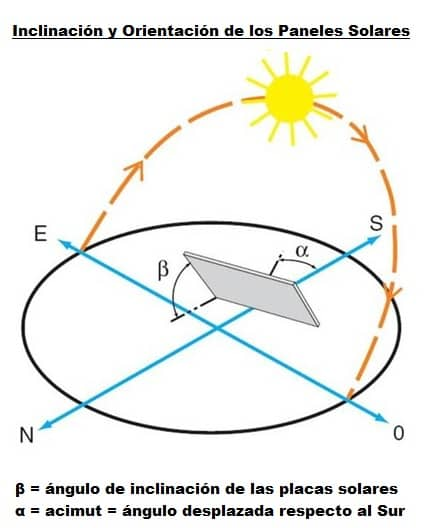

---

### Datos Requeridos
Al ejecutar la celda, se deberán ingresar los siguientes parámetros:

1.  **Configuración física**: Cantidad de paneles en serie ($N_s$) y en paralelo ($N_p$).
2.  **Geometría**: Ángulo de inclinación ($\beta$) y Azimut ($\alpha$).
3.  **Especificaciones eléctricas**: Voltaje ($V_{oc}$), Corriente ($I_{sc}$), temperatura NOCT y coeficientes de temperatura ($\alpha_{Isc}, \beta_{Voc}$).

In [2]:
# =============================================================================
# CELDA 1: CARGA DE DATOS Y CONFIGURACIÓN DINÁMICA (SIN VALORES PREVIOS)
# =============================================================================

import re
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# 1. IDENTIFICACIÓN Y LECTURA AUTOMÁTICA DEL ARCHIVO
FILE_NAME = 'Datos.csv'
lat_nasa, lon_nasa = None, None
data_start_row = 0

try:
    with open(FILE_NAME, 'r') as f:
        for i, line in enumerate(f):
            if "Latitude" in line and "Longitude" in line:
                coords = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                lat_nasa, lon_nasa = float(coords[0]), float(coords[1])
            if line.startswith("YEAR"):
                data_start_row = i
                break
    print(f"📍 Ubicación detectada: Lat {lat_nasa}, Lon {lon_nasa}")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{FILE_NAME}'.")

# 2. PROCESAMIENTO DE LA SERIE DE TIEMPO
df = pd.read_csv(FILE_NAME, skiprows=data_start_row)
df = df[df['ALLSKY_SFC_SW_DWN'] != -999.0].reset_index(drop=True)
df['Time'] = pd.to_datetime(dict(year=df.YEAR, month=df.MO, day=df.DY, hour=df.HR))
df = df.set_index('Time').tz_localize('Etc/GMT+5')

print(f"✅ Datos cargados: {len(df)} registros procesados.\n")

# 3. CREACIÓN DE FORMULARIO INTERACTIVO (WIDGETS VACÍOS)
style = {'description_width': '180px'}
layout = widgets.Layout(width='400px')

print("--- CONFIGURACIÓN DEL SISTEMA PV ---")
# Se establece value=None para forzar la entrada manual del usuario
w_ns = widgets.IntText(value=None, description='Paneles en SERIE (Ns):', style=style, layout=layout)
w_np = widgets.IntText(value=None, description='Ramas en PARALELO (Np):', style=style, layout=layout)
w_beta = widgets.FloatText(value=None, description='Inclinación β [°]:', style=style, layout=layout)
w_alpha = widgets.FloatText(value=None, description='Azimut α [180=S, 0=N]:', style=style, layout=layout)
w_voc = widgets.FloatText(value=None, description='Voltaje Voc [V]:', style=style, layout=layout)
w_isc = widgets.FloatText(value=None, description='Corriente Isc [A]:', style=style, layout=layout)
w_bvoc = widgets.FloatText(value=None, description='Coef. Temp Voc [V/°C]:', style=style, layout=layout)
w_aisc = widgets.FloatText(value=None, description='Coef. Temp Isc [A/°C]:', style=style, layout=layout)
w_noct = widgets.FloatText(value=None, description='Temp NOCT [°C]:', style=style, layout=layout)

ui = widgets.VBox([w_ns, w_np, w_beta, w_alpha, w_voc, w_isc, w_bvoc, w_aisc, w_noct])
display(ui)

📍 Ubicación detectada: Lat 4.6024, Lon -74.0629
✅ Datos cargados: 1440 registros procesados.

--- CONFIGURACIÓN DEL SISTEMA PV ---


# 2. Motor Geométrico y Transposición de Irradiancia

En esta etapa se realiza la conversión de la irradiancia horizontal captada por la NASA a la irradiancia real que incide sobre la superficie inclinada del arreglo fotovoltaico ($G_{poa}$). 

### 2.1 Posición Solar y Ángulo de Incidencia
El cálculo de la trayectoria solar se determina mediante el ángulo cenital ($\theta_z$) y el azimut solar ($\gamma_s$). La relación entre la posición del sol y la orientación del panel permite obtener el **Ángulo de Incidencia ($\theta_{AOI}$)**, factor crítico que define la perpendicularidad del impacto de los rayos solares:

$$\cos(\theta_{AOI}) = \cos(\theta_z) \cos(\beta) + \sin(\theta_z) \sin(\beta) \cos(\gamma_s - \alpha)$$

### 2.2 Componentes de la Irradiancia en el Plano (POA)
La energía total disponible para la conversión fotovoltaica se compone de tres fuentes distintas, como se ilustra en la siguiente imagen:

1.  **Radiación Directa**: Componente que viaja en línea recta desde el disco solar.
2.  **Radiación Difusa**: Energía dispersada por la atmósfera y nubes que incide desde múltiples ángulos del cielo.
3.  **Radiación Reflejada (Albedo)**: Fracción de la irradiancia global que rebota en el suelo y es captada por el arreglo.



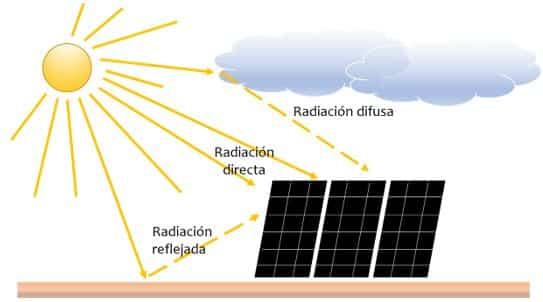


### Funciones de la celda de procesamiento:
*   Asignación de las variables configuradas en los controles interactivos de la Celda 1.
*   Cálculo de la posición solar horaria exacta para las coordenadas detectadas.
*   Generación de la serie de tiempo de **Irradiancia Efectiva ($G_{poa}$)** en $W/m^2$.

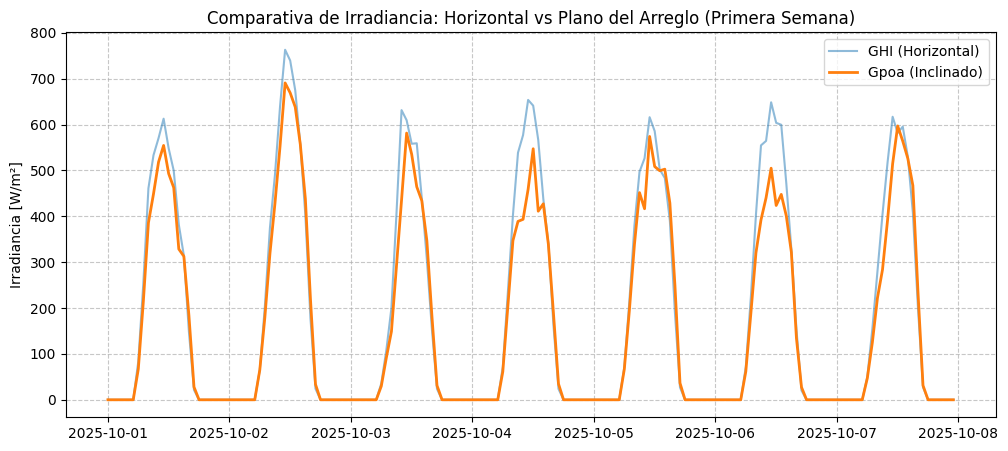

✅ Transposición completada exitosamente.
Irradiancia máxima calculada en el panel: 775.93 W/m²


In [7]:

# 1. ASIGNACIÓN DE VARIABLES DESDE LOS WIDGETS
Ns = w_ns.value
Np = w_np.value
beta_panel = w_beta.value
alpha_panel = w_alpha.value
Voc_stc = w_voc.value
Isc_stc = w_isc.value
beta_voc = w_bvoc.value
alpha_isc = w_aisc.value
noct_panel = w_noct.value

# 2. CÁLCULO DE LA POSICIÓN SOLAR
solpos = pvlib.solarposition.get_solarposition(
    time=df.index,
    latitude=lat_nasa,
    longitude=lon_nasa,
    altitude=2550 
)

# 3. CÁLCULO DE IRRADIANCIA EXTRATERRESTRE (Requerido por el modelo Hay-Davies)
# dni_extra calcula la radiación en el tope de la atmósfera para cada marca de tiempo
dni_extra = pvlib.irradiance.get_extra_radiation(df.index)

# 4. TRANSPOSICIÓN DE IRRADIANCIA (MODELO HAY-DAVIES)
poa_irradiance = pvlib.irradiance.get_total_irradiance(
    surface_tilt=beta_panel,
    surface_azimuth=alpha_panel,
    dni=df['ALLSKY_SFC_SW_DNI'],
    ghi=df['ALLSKY_SFC_SW_DWN'],
    dhi=df['ALLSKY_SFC_SW_DIFF'],
    solar_zenith=solpos['zenith'],
    solar_azimuth=solpos['azimuth'],
    dni_extra=dni_extra,  # <--- Parámetro añadido para corregir el error
    model='haydavies'
)

# Almacenamiento del resultado principal (Gpoa) en el DataFrame
df['Gpoa'] = poa_irradiance['poa_global']

# 5. VISUALIZACIÓN DE RESULTADOS
plt.figure(figsize=(12, 5))
plt.plot(df.index[:168], df['ALLSKY_SFC_SW_DWN'][:168], label='GHI (Horizontal)', alpha=0.5)
plt.plot(df.index[:168], df['Gpoa'][:168], label='Gpoa (Inclinado)', linewidth=2)
plt.title('Comparativa de Irradiancia: Horizontal vs Plano del Arreglo (Primera Semana)')
plt.ylabel('Irradiancia [W/m²]')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"✅ Transposición completada exitosamente.")
print(f"Irradiancia máxima calculada en el panel: {df['Gpoa'].max():.2f} W/m²")


# 3. Modelo Térmico (Temperatura de Célula)
La eficiencia de un panel fotovoltaico depende de la temperatura interna de sus células ($T_{cell}$), la cual es superior a la temperatura ambiente debido a la absorción de radiación. Se utiliza el modelo **NOCT** (*Normal Operating Cell Temperature*) para estimar este valor:

$$T_{cell} = T_{amb} + G_{poa} \cdot \left( \frac{NOCT - 20}{800} \right)$$

Donde:
*   **$T_{amb}$**: Temperatura ambiente obtenida de la NASA ($T2M$).
*   **$G_{poa}$**: Irradiancia efectiva sobre el plano del arreglo.
*   **NOCT**: Parámetro nominal del fabricante ingresado en la Celda 1.

### 3.2 Ajuste de Parámetros Eléctricos
Las variaciones de luz y temperatura afectan de manera distinta a los componentes de potencia:

1.  **Corriente del Arreglo ($I_{array}$)**: Varía de forma directamente proporcional a la irradiancia.
    $$I_{array} = [I_{sc\_stc} \cdot N_p] \cdot \left( \frac{G_{poa}}{1000} \right) \cdot [1 + \alpha_{Isc}(T_{cell} - 25)]$$

2.  **Voltaje del Arreglo ($V_{array}$)**: Se reduce ante incrementos de temperatura y aumenta logarítmicamente con la irradiancia.
    $$V_{array} = [V_{oc\_stc} \cdot N_s] + \beta_{Voc}(T_{cell} - 25) + V_t \cdot \ln \left( \frac{G_{poa}}{1000} \right)$$

Donde **$N_s$** y **$N_p$** representan la cantidad de paneles en serie y paralelo, mientras que **$\alpha_{Isc}$** y **$\beta_{Voc}$** son los coeficientes de temperatura del panel.


### Funciones de la celda de cálculo eléctrico:
*   Estimación de la temperatura de operación de las células para cada registro horario.
*   Cálculo de las series de tiempo de Voltaje ($V_{set}$) y Corriente ($I_{set}$) escaladas al tamaño del arreglo.
*   Generación de gráficas de potencia esperada para validación previa a la conexión con la fuente DC.

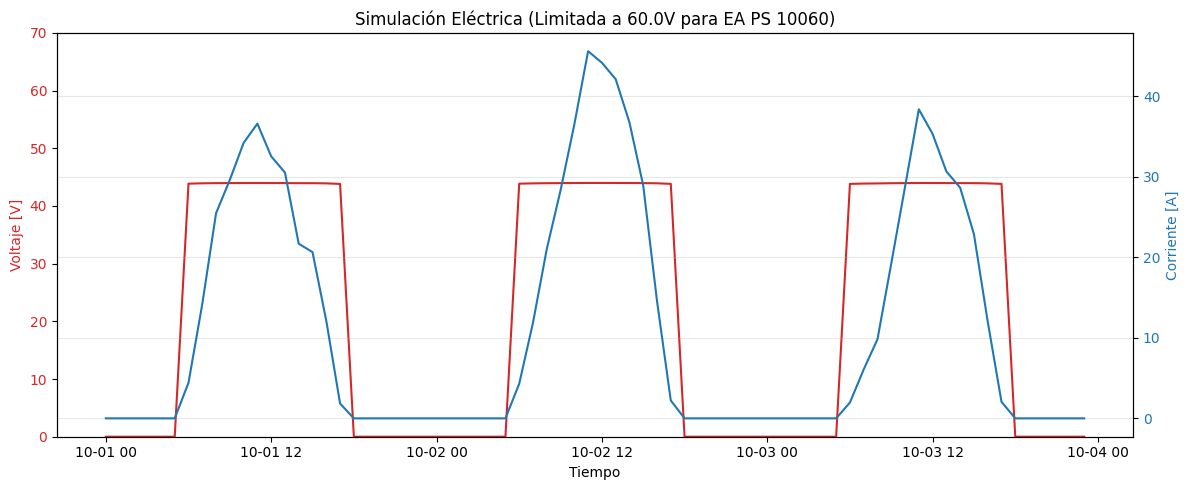

✅ Cálculos finalizados. Voltaje máximo en secuencia: 43.99 V


In [15]:
# =============================================================================
# CELDA 3: MODELO TÉRMICO Y ELÉCTRICO DEL ARREGLO PV (CON FILTRO DE SEGURIDAD 60V)
# =============================================================================

# 1. CÁLCULO DE LA TEMPERATURA DE LA CÉLULA (MODELO NOCT)
df['Tcell'] = df['T2M'] + df['Gpoa'] * ((noct_panel - 20) / 800)

# 2. CÁLCULO DE CORRIENTE DEL ARREGLO (Iset)
df['I_set'] = (Isc_stc * Np) * (df['Gpoa'] / 1000) * (1 + alpha_isc * (df['Tcell'] - 25))

# 3. CÁLCULO DE VOLTAJE DEL ARREGLO (Vset)
vt_array = 0.026 * Ns 
df['V_set'] = (Voc_stc * Ns) + (beta_voc * (df['Tcell'] - 25)) + vt_array * np.log(np.maximum(df['Gpoa'], 1) / 1000)

# --- CONTROL DE SEGURIDAD PARA HARDWARE EA (60V) ---
V_MAX_FUENTE = 60.0
v_calculado_max = df['V_set'].max()

if v_calculado_max > V_MAX_FUENTE:
    print(f"⚠️ ATENCIÓN: El voltaje calculado ({v_calculado_max:.2f}V) supera el límite de tu fuente (60V).")
    print(f"Ajustando (clipping) el voltaje a {V_MAX_FUENTE}V para proteger el equipo.")
    df['V_set'] = df['V_set'].clip(upper=V_MAX_FUENTE)
# ---------------------------------------------------

# 4. FILTRO DE SEGURIDAD (Condiciones Nocturnas)
df.loc[df['Gpoa'] < 5, ['I_set', 'V_set']] = 0
df['P_set'] = df['V_set'] * df['I_set']

# 5. VISUALIZACIÓN
fig, ax1 = plt.subplots(figsize=(12, 5))
color = 'tab:red'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Voltaje [V]', color=color)
ax1.plot(df.index[:72], df['V_set'][:72], color=color, label='V_set')
ax1.set_ylim(0, V_MAX_FUENTE + 10) # Escala ajustada a la fuente
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Corriente [A]', color=color)
ax2.plot(df.index[:72], df['I_set'][:72], color=color, label='I_set')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Simulación Eléctrica (Limitada a {V_MAX_FUENTE}V para EA PS 10060)')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

print(f"✅ Cálculos finalizados. Voltaje máximo en secuencia: {df['V_set'].max():.2f} V")

# 4. Estrategia de Simulación y Configuración de Salida

En esta etapa se define la modalidad de los datos y la dinámica temporal de la prueba. El sistema permite adaptar la base de datos maestra para generar una secuencia optimizada para la fuente EA.

### 4.1 Modalidades de Datos
Se presentan tres estrategias para procesar la serie de tiempo climática:
*   **Serie Completa**: Mantiene la cronología total de los registros cargados.
*   **Solo Día (06:00 - 18:00)**: Filtra los periodos de oscuridad para centrar la simulación en las horas de generación efectiva.
*   **Día Promedio**: Consolida toda la base de datos en un único perfil de 24 horas basado en promedios estadísticos por cada hora del día.

### 4.2 Control de Tiempo y Escalado (Milisegundos)
La velocidad de la simulación es determinada por el usuario mediante la asignación de milisegundos por cada registro horario de la NASA. 
*   **Cálculo Automático**: El sistema descompone el valor ingresado en las columnas de Horas, Minutos, Segundos y Milisegundos requeridas por el formato de la fuente DC.
*   **Gestión de Salida**: El estado de la salida de potencia (`ON/OFF`) se programa automáticamente; se desactiva en registros donde la potencia calculada sea nula para proteger el hardware.

### Funciones de la celda de procesamiento:
*   Selección interactiva de la estrategia de filtrado.
*   Definición del intervalo de tiempo real por cada paso de simulación.
*   Generación y exportación del archivo final `Secuencia_Simulacion_PV.csv` con delimitadores y encabezados compatibles.

In [13]:

import csv
import ipywidgets as widgets
from IPython.display import display

# 1. INTERFAZ DE CONFIGURACIÓN UNIFICADA
style = {'description_width': 'initial'}
layout = widgets.Layout(width='450px')

print("--- CONFIGURACIÓN DE LA SECUENCIA DE SALIDA ---")

w_estrategia = widgets.Dropdown(
    options=[
        ('Serie Completa (Cronológica)', 'full'),
        ('Solo Día (06:00 - 18:00)', 'day'),
        ('Día Promedio (Perfil Estadístico)', 'average')
    ],
    value='full',
    description='Estrategia de simulación:',
    style=style, layout=layout
)

w_ms_per_step = widgets.IntText(
    value=1000, 
    description='Milisegundos por paso (Hora NASA):', 
    style=style, layout=layout
)

btn_generar = widgets.Button(
    description="Generar y Exportar CSV", 
    button_style='success',
    layout=widgets.Layout(width='200px', margin='10px 0 0 180px')
)

output_final = widgets.Output()

# 2. LÓGICA DE PROCESAMIENTO Y EXPORTACIÓN
def ejecutar_simulacion(b):
    with output_final:
        output_final.clear_output()
        
        # A. Aplicación de la Estrategia de Filtrado
        estrategia = w_estrategia.value
        if estrategia == 'full':
            df_proc = df[['V_set', 'I_set', 'P_set']].copy()
        elif estrategia == 'day':
            df_proc = df[(df.index.hour >= 6) & (df.index.hour <= 18)][['V_set', 'I_set', 'P_set']].copy()
        elif estrategia == 'average':
            df_proc = df.groupby(df.index.hour)[['V_set', 'I_set', 'P_set']].mean()

        # B. Descomposición del Tiempo (Conversión de ms a H:M:S:ms)
        t_total_ms = w_ms_per_step.value
        h_col = t_total_ms // 3600000
        m_col = (t_total_ms % 3600000) // 60000
        s_col = (t_total_ms % 60000) // 1000
        ms_col = t_total_ms % 1000

        # C. Generación de Estructura de Datos para Fuente EA
        OUTPUT_FILENAME = "Secuencia_Simulacion_PV.csv"
        FIELDNAMES = [
            "Step", "Description", "U set (V)", "I set (A)", "P set (W)",
            "Output/Input", "Hour", "Minute", "Second", "Millisecond", "R mode", "R set"
        ]
        
        rows_to_export = []
        for i, (idx, row) in enumerate(df_proc.iterrows(), start=1):
            # Determinación de estado de salida
            output_state = "ON" if row['P_set'] > 0 else "OFF"
            
            rows_to_export.append({
                "Step": i,
                "Description": f"Paso {i} | Estrategia: {estrategia}",
                "U set (V)": f"{row['V_set']:.3f}",
                "I set (A)": f"{row['I_set']:.3f}",
                "P set (W)": f"{row['P_set']:.3f}",
                "Output/Input": output_state,
                "Hour": h_col,
                "Minute": m_col,
                "Second": s_col,
                "Millisecond": ms_col,
                "R mode": "OFF",
                "R set": "1"
            })

        # D. Escritura del Archivo de Salida
        try:
            with open(OUTPUT_FILENAME, "w", newline="", encoding="utf-8") as f:
                writer = csv.DictWriter(f, fieldnames=FIELDNAMES, delimiter=";", lineterminator="\n")
                writer.writeheader()
                writer.writerows(rows_to_export)
            
            print(f"✅ Secuencia generada con éxito: {OUTPUT_FILENAME}")
            print(f"📊 Registros exportados: {len(rows_to_export)}")
            print(f"⏱️ Tiempo real por paso: {h_col}h {m_col}m {s_col}s {ms_col}ms")
            
            # Previsualización gráfica de la potencia resultante
            plt.figure(figsize=(10, 3))
            plt.plot(range(len(df_proc)), df_proc['P_set'], color='darkgreen', linewidth=1.5)
            plt.fill_between(range(len(df_proc)), df_proc['P_set'], color='green', alpha=0.2)
            plt.title("Perfil de Potencia de la Secuencia Exportada")
            plt.xlabel("Número de Paso")
            plt.ylabel("Potencia [W]")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()

        except Exception as e:
            print(f"❌ Error en la generación del archivo: {e}")

# 3. EJECUCIÓN DE LA INTERFAZ
btn_generar.on_click(ejecutar_simulacion)
ui_final = widgets.VBox([w_estrategia, w_ms_per_step, btn_generar, output_final])
display(ui_final)

--- CONFIGURACIÓN DE LA SECUENCIA DE SALIDA ---


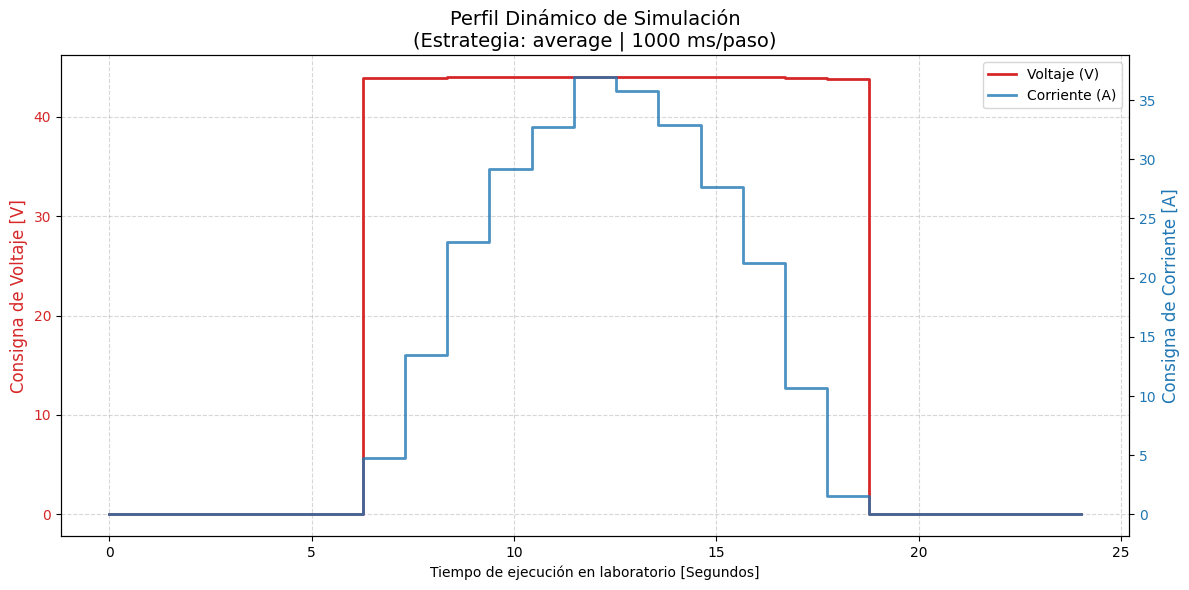

✅ Gráfica generada exitosamente.
⏱️ Duración total de la prueba en laboratorio: 24.00 segundos.


In [14]:

import numpy as np

# 1. VALIDACIÓN DE DATOS PROCESADOS
# Intentamos recuperar df_proc de la celda anterior (ejecutada mediante el botón)
try:
    # Nota: df_proc debe ser accesible. Si se generó dentro de la función, 
    # la recuperamos desde la lógica de la celda anterior.
    if 'df_proc' not in locals() and 'df_proc' not in globals():
        # Si el usuario no presionó el botón, intentamos generar una copia local rápida
        estrategia = w_estrategia.value
        if estrategia == 'full': df_plot = df[['V_set', 'I_set']].copy()
        elif estrategia == 'day': df_plot = df[(df.index.hour >= 6) & (df.index.hour <= 18)][['V_set', 'I_set']].copy()
        elif estrategia == 'average': df_plot = df.groupby(df.index.hour)[['V_set', 'I_set']].mean()
    else:
        df_plot = df_proc # Usar la ya generada por el botón
    
    # 2. CÁLCULO DEL VECTOR DE TIEMPO REAL (Segundos)
    ms_por_paso = w_ms_per_step.value
    tiempo_total_segundos = (len(df_plot) * ms_por_paso) / 1000
    vector_tiempo = np.linspace(0, tiempo_total_segundos, len(df_plot))

    # 3. GENERACIÓN DEL GRÁFICO DE DOBLE EJE
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eje para Voltaje
    color_v = 'tab:red'
    ax1.set_xlabel('Tiempo de ejecución en laboratorio [Segundos]')
    ax1.set_ylabel('Consigna de Voltaje [V]', color=color_v, fontsize=12)
    ax1.step(vector_tiempo, df_plot['V_set'], color=color_v, where='post', linewidth=2, label='Voltaje (V)')
    ax1.tick_params(axis='y', labelcolor=color_v)
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)

    # Eje para Corriente
    ax2 = ax1.twinx()
    color_i = 'tab:blue'
    ax2.set_ylabel('Consigna de Corriente [A]', color=color_i, fontsize=12)
    ax2.step(vector_tiempo, df_plot['I_set'], color=color_i, where='post', linewidth=2, label='Corriente (A)', alpha=0.8)
    ax2.tick_params(axis='y', labelcolor=color_i)

    # Títulos y formato
    plt.title(f'Perfil Dinámico de Simulación\n(Estrategia: {w_estrategia.value} | {ms_por_paso} ms/paso)', fontsize=14)
    fig.tight_layout()
    
    # Añadir leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.show()

    print(f"✅ Gráfica generada exitosamente.")
    print(f"⏱️ Duración total de la prueba en laboratorio: {tiempo_total_segundos:.2f} segundos.")

except Exception as e:
    print(f"❌ Error al generar la gráfica: {e}")
    print("Asegúrese de haber presionado el botón 'Generar y Exportar CSV' en la Celda 4.")